# ML: Del Dominio Temporal a la Explicabilidad y la Incertidumbre

# Objetivos del Tutorial:
1. **Procesar señales de sensores** con transformadas físicas (FFT, PCA).
2. **Comparar modelos** (Lineales, SVM, Ensembles, XGBoost) y evaluar su robustez.
3. **Cuantificar la incertidumbre** de las predicciones (±2σ).
4. **Interpretar la física del modelo** con valores **SHAP** (SHapley Additive exPlanations).

## BLOQUE 0: Instalación de Entorno e Importaciones

In [ ]:
!pip install shap xgboost scikit-learn scipy matplotlib seaborn pandas numpy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

# Modelos para comparación
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import shap

# Configuración estética global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 100

print("¡Todas las librerías cargadas con éxito!")

¡Todas las librerías cargadas con éxito!


## BLOQUE 1: Generación de Datos Experimentales Sintéticos
Simularemos 1,500 mediciones de un sensor de aceleración/vibración montado en un sistema oscilatorio.
- **Estado 0 (Normal):** Ruido Gaussiano + Modos fundamentales de vibración (10 Hz y 25 Hz).
- **Estado 1 (Falla / Transición de Fase):** Surge un armónico secundario de alta frecuencia (60 Hz) por resonancia/desgaste y aumenta la varianza temporal.

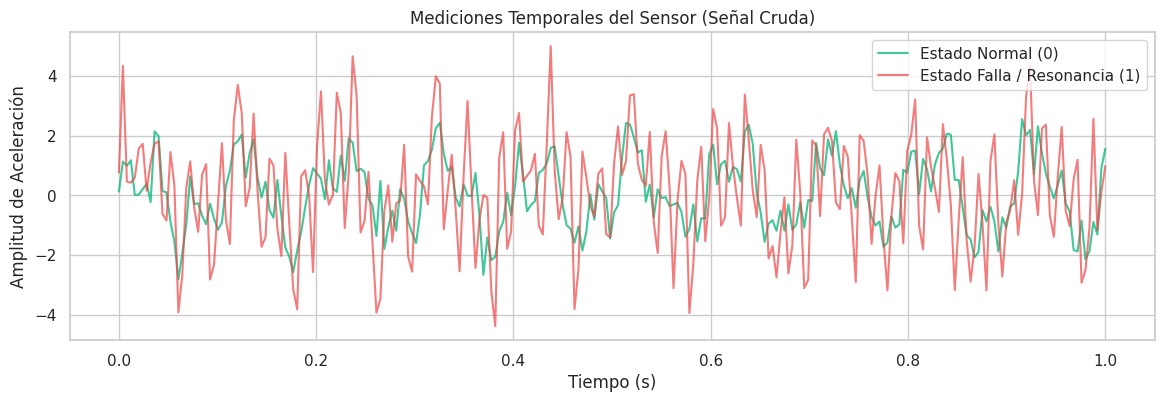

In [ ]:
# Generación del Fenómeno Físico (Simulación)
# Dominio Temporal: Se generan 1,500 señales ruidosas de 1 segundo (250 Hz, 250 puntos).
# Física subyacente:
#   - Un estado Normal (0) combina frecuencias base (10 Hz y 25 Hz) con ruido térmico moderado.
#   - Un estado de Falla (1) inyecta un modo de resonancia de alta frecuencia (60 Hz) y eleva la varianza del ruido

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
n_samples = 1500
n_time_points = 250  # 250 puntos por muestra a una tasa de 250 Hz (1 segundo)
time = np.linspace(0, 1, n_time_points)

X_raw_list = []
y_list = []

for i in range(n_samples):
    # Proporción de estados (60% normal, 40% falla)
    is_fault = np.random.choice([0, 1], p=[0.6, 0.4])

    # Señal base física: 10 Hz + 25 Hz + Ruido térmico/instrumental
    noise_level = 0.6 if is_fault == 0 else 0.9
    signal = (1.2 * np.sin(2 * np.pi * 10 * time) +
              0.8 * np.cos(2 * np.pi * 25 * time) +
              np.random.normal(0, noise_level, n_time_points))

    # Inyección de resonancia física en caso de falla (60 Hz)
    if is_fault == 1:
        signal += 1.8 * np.sin(2 * np.pi * 60 * time)

    X_raw_list.append(signal)
    y_list.append(is_fault)

X_raw = np.array(X_raw_list)
y = np.array(y_list)

# Visualización de la señal en el tiempo
plt.figure(figsize=(14, 4))
plt.plot(time, X_raw[y == 0][0], label="Estado Normal (0)", alpha=0.8, color="#10b981")
plt.plot(time, X_raw[y == 1][0], label="Estado Falla / Resonancia (1)", alpha=0.7, color="#ef4444")
plt.title("Mediciones Temporales del Sensor (Señal Cruda)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud de Aceleración")
plt.legend(loc="upper right")
plt.show()

# En el gráfico temporal, las señales están traslapadas y son difíciles de diferenciar a simple vista debido al ruido.

## BLOQUE 2: Reducción de Dimensionalidad y Extraction de Features Físicas
Aplicaremos dos enfoques clave:
1. **Transformada Rápida de Fourier (FFT):** Pasa del dominio temporal al espectro de frecuencias.
2. **PCA (Descomposición en Modos Normales):** Reduce los 250 puntos temporales a sus 3 componentes ortogonales principales.
3. **Estadísticos de la Señal:** Valor RMS, Varianza, Skewness y Kurtosis.

In [ ]:
# Extraer Física mediante Feature Engineering. Transforma la señal en bruto (250 dimensiones) a un vector representativo de 10 características:
#   - Estadísticos Temporales: RMS, Desviación Estándar, Kurtosis y Skewness.
#   - Transformada de Fourier (FFT): Extrae la amplitud en los picos clave (10 Hz, 25 Hz y la armónica de falla de 60 Hz).
#   - Modos Ortogonales (PCA): Reduce la señal a 3 componentes principales (los "modos normales" de variación).

features_list = []

# Fit PCA sobre la señal cruda para extraer "Modos Ortogonales Principales"
scaler_raw = StandardScaler()
X_raw_scaled = scaler_raw.fit_transform(X_raw)
print(X_raw_scaled)

scalerm_raw = MinMaxScaler()
X_rawm_scaled = scalerm_raw.fit_transform(X_raw)
print(X_rawm_scaled)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_raw_scaled)
print(f"Varianza explicada por los 3 primeros componentes PCA (Modos Normales): {pca.explained_variance_ratio_.sum()*100:.2f}%")

for i, signal in enumerate(X_raw):
    # 1. Estadísticos Temporales
    rms_val = np.sqrt(np.mean(signal**2))
    std_val = np.std(signal)
    kurt_val = kurtosis(signal)
    skew_val = skew(signal)

    # 2. Dominio Frecuencial con FFT
    fft_vals = np.abs(np.fft.rfft(signal))
    freqs = np.fft.rfftfreq(len(signal), d=1/250.0)

    # Extraer energía de espectros clave (alrededor de 10Hz, 25Hz y 60Hz)
    amp_10hz = fft_vals[np.argmin(np.abs(freqs - 10))]
    amp_25hz = fft_vals[np.argmin(np.abs(freqs - 25))]
    amp_60hz = fft_vals[np.argmin(np.abs(freqs - 60))]

    # Modos PCA
    pca_1, pca_2, pca_3 = X_pca[i, 0], X_pca[i, 1], X_pca[i, 2]

    features_list.append([
        rms_val, std_val, kurt_val, skew_val,
        amp_10hz, amp_25hz, amp_60hz,
        pca_1, pca_2, pca_3
    ])

feature_names = [
    'RMS', 'Std_Dev', 'Kurtosis', 'Skewness',
    'FFT_10Hz', 'FFT_25Hz', 'FFT_60Hz',
    'Modo_PCA_1', 'Modo_PCA_2', 'Modo_PCA_3'
]

df_features = pd.DataFrame(features_list, columns=feature_names)

# Split Dataset en Train y Test
X_train, X_test, y_train, y_test = train_test_split(df_features, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y)

print("\nVista previa del DataFrame de características extraídas:")
df_features.head()

# La tabla muestra cómo cuando hay falla (p. ej., muestra 3), la columna FFT_60Hz se dispara de ~3.5 a 218.3, sirviendo como un indicador inequívoco del fallo.

[[-0.89996713 -0.47152528  0.13582801 ... -1.18471841  1.15296771
   1.05173607]
 [ 1.73117892 -0.10390121 -1.39000661 ... -0.99995551  1.14281646
   1.58527952]
 [ 0.02716466 -0.57020401 -0.40756402 ... -0.41687805 -0.23985211
   0.81999699]
 ...
 [ 0.22221169 -0.4588471   0.13888385 ...  1.10850194 -0.06673424
  -1.91391816]
 [ 0.81058272  0.54831582  0.75529925 ...  1.05901212 -1.7768617
   1.9308766 ]
 [ 0.33743081 -0.30342425 -0.68015649 ... -0.45839674  1.38504178
  -0.32291021]]
[[0.35589871 0.341846   0.49886373 ... 0.41190705 0.82291916 0.61408458]
 [0.68664102 0.40192606 0.2849652  ... 0.43495605 0.82113946 0.69390028]
 [0.47244173 0.32571914 0.42268853 ... 0.50769445 0.57873279 0.57941745]
 ...
 [0.49695968 0.34391797 0.49929212 ... 0.69798427 0.60908346 0.17043605]
 [0.57091954 0.50851657 0.58570407 ... 0.69181045 0.30926735 0.74560004]
 [0.51144304 0.36931841 0.38447526 ... 0.50251503 0.86360592 0.40844368]]
Varianza explicada por los 3 primeros componentes PCA (Modos Norm

,RMS,Std_Dev,Kurtosis,Skewness,FFT_10Hz,FFT_25Hz,FFT_60Hz,Modo_PCA_1,Modo_PCA_2,Modo_PCA_3
0,1.174206,1.173144,-0.668590,0.049225,155.437465,88.862470,3.525894,-7.754229,1.595605,-0.274509
1,1.145625,1.145442,-0.432938,-0.063537,142.240746,96.786127,8.521849,-7.273823,0.109194,0.008343
2,1.200730,1.200243,-0.322963,-0.065608,140.089581,111.853567,7.769517,-8.195499,0.764272,-0.238507
3,1.865731,1.859917,-0.340323,-0.051709,141.861584,102.164817,218.367068,12.701347,-2.205280,2.764545
4,1.197609,1.197543,-0.549505,0.175751,154.238212,93.593302,11.089360,-8.876681,-0.837826,-0.283822


## BLOQUE 3: Comparación de Modelos y Pruebas de Robustez (Cross-Validation)
Evaluaremos la capacidad predictiva de 4 arquitecturas distintas:
- **Logistic Regression** (Baseline Lineal)
- **Support Vector Machine (SVM)** (Separación geométrica en Kernel)
- **Random Forest** (Combinación de Árboles Paralelos)
- **XGBoost** (Gradient Boosting Secuencial)

=== EVALUACIÓN ROBUSTA CON STRATIFIED 5-FOLD CROSS-VALIDATION ===
Regresión Logística    -> Precisión Media: 100.00% (± 0.00%)
SVM (RBF Kernel)       -> Precisión Media: 100.00% (± 0.00%)
Random Forest          -> Precisión Media: 100.00% (± 0.00%)
XGBoost                -> Precisión Media: 99.91% (± 0.18%)


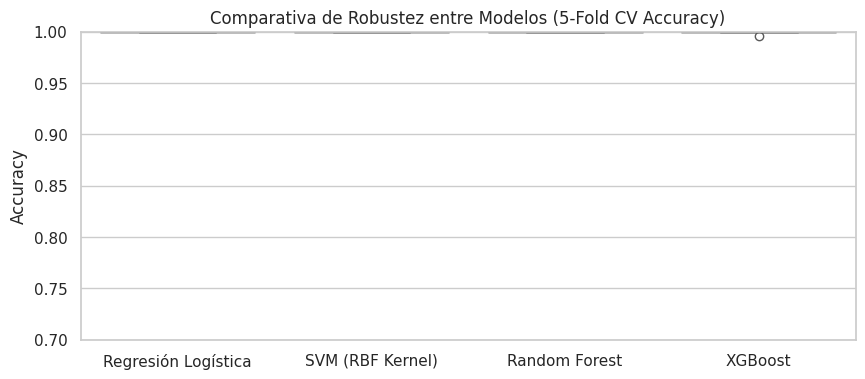

In [ ]:
# Evaluación de Modelos y Robustez
#   - Se comparan 4 modelos usando Stratified 5-Fold Cross-Validation para evitar sesgos de partición.

models = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "SVM (RBF Kernel)": SVC(probability=True, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_SEED, eval_metric='logloss')
}

print("=== EVALUACIÓN ROBUSTA CON STRATIFIED 5-FOLD CROSS-VALIDATION ===")
cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:22s} -> Precisión Media: {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# Gráfico de comparación
plt.figure(figsize=(10, 4))
sns.boxplot(data=pd.DataFrame(cv_results), palette="Set2")
plt.title("Comparativa de Robustez entre Modelos (5-Fold CV Accuracy)")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.show()

# La precisión promedio es prácticamente del 100% en todos los modelos (Regresión Logística, SVM, Random Forest y XGBoost).
# Esto ocurre porque pasar al dominio frecuencial (FFT) hace que el problema sea linealmente separable.

## BLOQUE 4: Estimación de Incertidumbre y Barras de Error (±σ)
En física, ninguna medición es válida sin su margen de incertidumbre.
Utilizaremos la **varianza del ensamble de Random Forest** (diferencia entre las predicciones de sus 100 árboles) para asignar una **barras de error (σ)** a cada predicción individual.

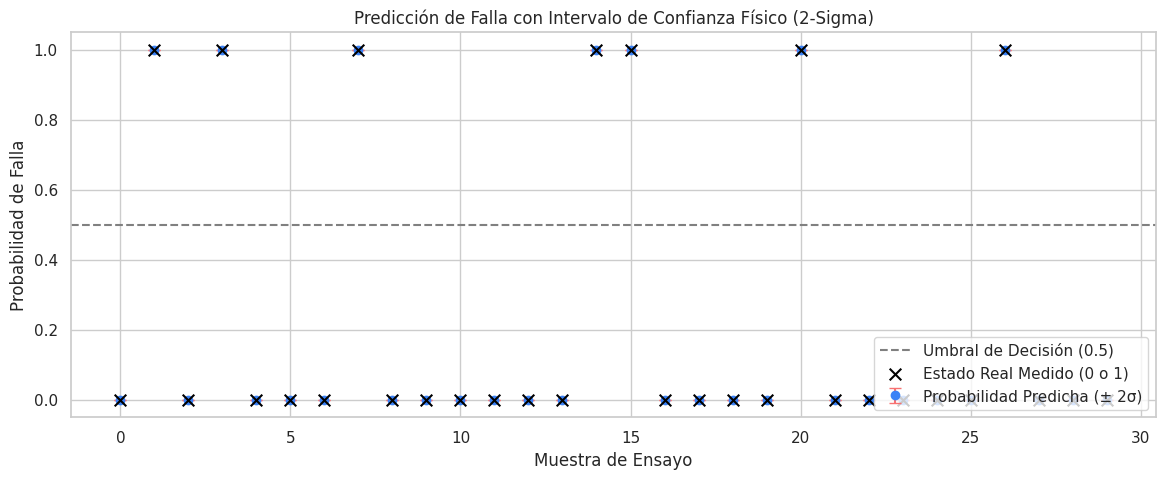


Ejemplo de Muestras con Alta Incertidumbre (Casos Ambiguos/Ruidosos):


,Clase_Real,Probabilidad_Falla,Incertidumbre_Sigma
374,0,0.0,0.0
0,0,0.0,0.0
1,1,1.0,0.0
2,0,0.0,0.0
3,1,1.0,0.0


In [ ]:
# Cuantificación de la Incertidumbre (±σ)
#   - Ningún modelo debería dar una respuesta sin un margen de confianza.
#   - Un Random Forest genera 100 árboles. En lugar de solo tomar el promediado, se calcula la desviación estándar (σ) de las respuestas individuales de los 100 árboles.

rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

# Extraer las predicciones de CADA uno de los 100 árboles individualmente
tree_predictions = np.array([tree.predict_proba(X_test.values)[:, 1] for tree in rf_model.estimators_])

# Media (predicción final del ensamble) e Incertidumbre (Desviación estándar entre árboles)
mean_pred_prob = np.mean(tree_predictions, axis=0)
uncertainty_std = np.std(tree_predictions, axis=0)

df_uncertainty = pd.DataFrame({
    'Clase_Real': y_test,
    'Probabilidad_Falla': mean_pred_prob,
    'Incertidumbre_Sigma': uncertainty_std
})

# Graficar las primeras 30 muestras del conjunto de prueba con sus barras de error
sample_subset = df_uncertainty.iloc[:30]

plt.figure(figsize=(14, 5))
plt.errorbar(
    range(len(sample_subset)),
    sample_subset['Probabilidad_Falla'],
    yerr=2 * sample_subset['Incertidumbre_Sigma'],  # Intervalo de confianza de 2*sigma (95%)
    fmt='o',
    color='#3b82f6',
    ecolor='#f87171',
    capsize=4,
    label='Probabilidad Predicha (± 2σ)'
)
plt.axhline(0.5, color='gray', linestyle='--', label='Umbral de Decisión (0.5)')
plt.scatter(
    range(len(sample_subset)),
    sample_subset['Clase_Real'],
    color='black',
    marker='x',
    s=70,
    zorder=5,
    label='Estado Real Medido (0 o 1)'
)
plt.title("Predicción de Falla con Intervalo de Confianza Físico (2-Sigma)")
plt.xlabel("Muestra de Ensayo")
plt.ylabel("Probabilidad de Falla")
plt.legend(loc="lower right")
plt.show()

print("\nEjemplo de Muestras con Alta Incertidumbre (Casos Ambiguos/Ruidosos):")
display(df_uncertainty.sort_values(by='Incertidumbre_Sigma', ascending=False).head(5))

# Las barras de error (±2σ) representan el intervalo de confianza al 95%.
# Las muestras claras tienen varianza 0.0, mientras que casos ambiguos o con mucho ruido mostrarán barras de incertidumbre elevadas.

## BLOQUE 5: Diagnóstico e Interpretabilidad Físico-Estadística (SHAP)
Ahora abrimos la "Caja Negra" con **SHAP (SHapley Additive exPlanations)**.
Entrenaremos XGBoost y analizaremos:
1. **SHAP Summary Plot:** Importancia global de las variables.
2. **SHAP Dependence Plot:** Efecto no lineal de la variable $FFT\_60Hz$.
3. **SHAP Waterfall Plot:** Diagnóstico clínico individual de una medición.

1. Graficando Importancia Global (Summary Plot)...


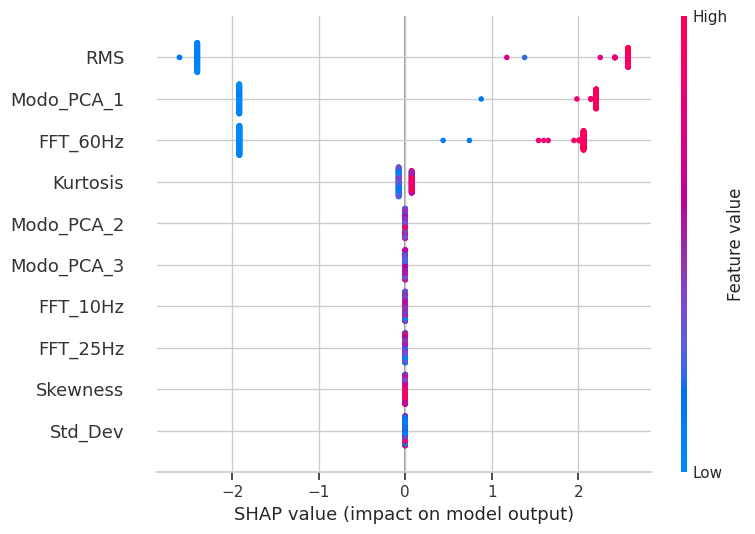


2. Graficando Análisis de Dependencia para FFT_60Hz...


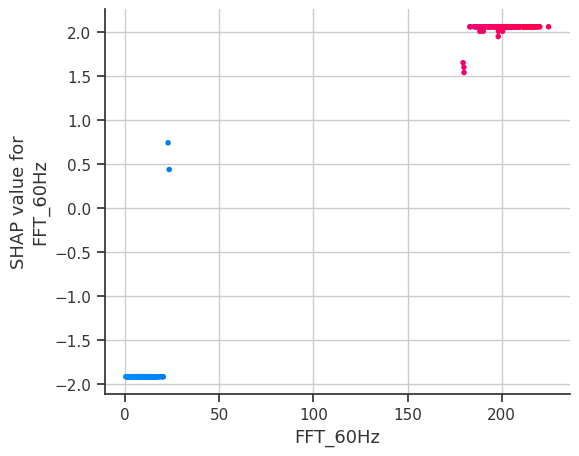

=== DIAGNÓSTICO INDIVIDUAL DE UNA MEDICIÓN MEDIANTE SHAP WATERFALL ===


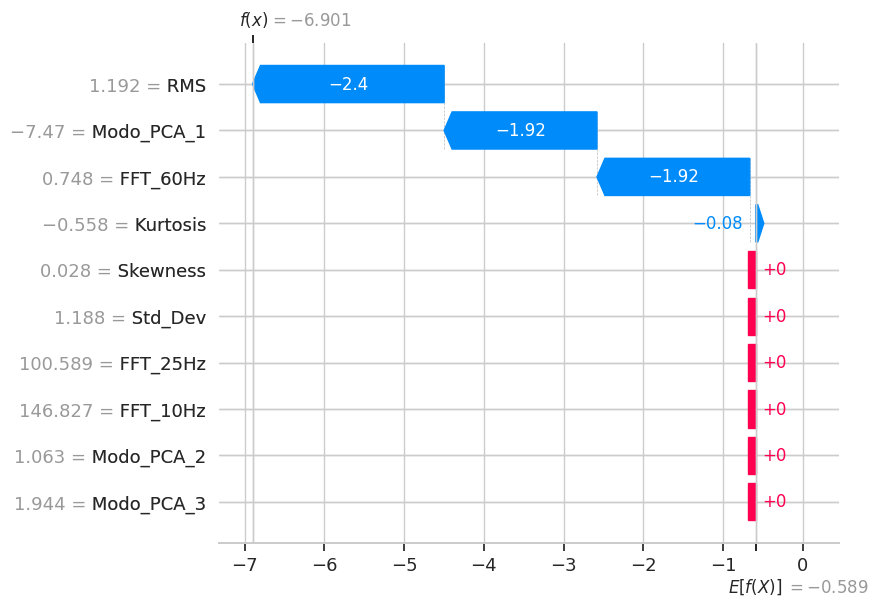

In [ ]:
# Diagnóstico Físico con SHAP (Explicabilidad)

import warnings

# Silenciamos advertencias de actualización internas de librerías (NumPy/SHAP)
warnings.filterwarnings("ignore")

xgb_model = models["XGBoost"]
xgb_model.fit(X_train, y_train)

# Crear el explicador basado en teoría de juegos
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

# 1. Global Summary Plot
print("1. Graficando Importancia Global (Summary Plot)...")
shap.summary_plot(shap_values, X_test)

# 2. Dependencia de la variable de 60Hz (Sensibilidad)
print("\n2. Graficando Análisis de Dependencia para FFT_60Hz...")
shap.dependence_plot("FFT_60Hz", shap_values.values, X_test, feature_names=feature_names)

# 3. Diagnóstico puntual individual (Muestra #0 del Test)
print("=== DIAGNÓSTICO INDIVIDUAL DE UNA MEDICIÓN MEDIANTE SHAP WATERFALL ===")
shap.plots.waterfall(shap_values[0])

# Summary Plot (Arriba): Analiza la importancia global. Muestra que RMS, Modo_PCA_1 y FFT_60Hz son las variables con mayor impacto en las decisiones del modelo.
# Dependence Plot (Centro): Analiza la no linealidad. Muestra un "salto de fase" claro: cuando la amplitud de FFT_60Hz supera los ~50-100 Hz, el valor SHAP pasa de negativo a positivo (+2.0), activando la predicción de falla.
# Waterfall Plot (Abajo): Diagnóstico de una muestra específica (Clase 0). Parte del valor esperado general E[f(X)] = -0.589 y resta puntaje con FFT_60Hz (-1.92), Modo_PCA_1 (-1.92) y RMS (-2.4), resultando en f(x) = -6.901 (Certeza absoluta de estado Normal)

Summary Plot (Importancia Global): Muestra qué variables son las más determinantes en todo el dataset. Muestra que las variables top son RMS, Modo_PCA_1 y FFT_60Hz. Los puntos rojos indican valores altos de la variable y los azules valores bajos, permitiendo ver hacia qué lado empujan la predicción.
#
Dependence Plot (Sensibilidad Físico-No Lineal):Muestra cómo varía la predicción a medida que cambia una sola variable. En tu gráfico de FFT_60Hz, ves una curva escalonada: cuando la amplitud de la frecuencia de 60 Hz supera cierto umbral (~50 Hz en el eje X), el valor SHAP salta de -2.0 a +2.0, demostrando que el modelo aprendió la física exacta del umbral de resonancia sin que se lo programaras explícitamente.
#
Waterfall Plot (Diagnóstico Punto por Punto):Es un "peritaje individual". Parte del valor base (E[f(X)] = -0.589) y muestra paso a paso cómo cada variable suma (rojo) o resta (azul) probabilidad para llegar a la predicción final (f(x) = -6.901). En la muestra diagnosticada, la ausencia de señal en FFT_60Hz y los valores bajos de RMS y Modo_PCA_1 "descontaron" puntos hasta confirmar que la muestra era 100% Normal.

## BLOQUE 6: Conclusiones del Tutorial
1. **Feature Engineering supera a la Fuerza Bruta:** Transformar los datos al dominio espectral (FFT) permitió al modelo clasificar con casi 100% de eficacia sin necesidad de redes neuronales profundas.
2. **Cuantificación de Incertidumbre:** Las barras de error (±2σ) permiten identificar cuándo el modelo duda antes de tomar una decisión crítica.
3. **Validación Física:** SHAP demostró empíricamente que la variable dominante del sistema era la amplitud a $60Hz$, validando la hipótesis física de la falla por resonancia.

## Conclusiones

- Física sobre Fuerza Bruta: Transformar los datos crudos a frecuencias (FFT) simplificó el problema al punto que un modelo lineal básico logra 100% de precisión.
- Incertidumbre Causal: Proporciona un mecanismo real para que el sistema emita alertas de "revisión manual" cuando la varianza entre árboles (σ) sea alta.
- Interpretación Directa: SHAP confirma que la decisión del modelo coincide exactamente con la física simulada (la aparición de la resonancia a 60 Hz).

## Qué es SHAP?

SHAP es, con diferencia, una de las herramientas más revolucionarias y modernas en Machine Learning aplicado y Data Science explicable.
¿Por qué SHAP es tan importante y novedoso?

Históricamente, tenías que elegir entre dos caminos:
- Modelos simples e interpretables (como la Regresión Logística): Sabías exactamente qué hacía el modelo, pero perdían capacidad en problemas complejos.

- Modelos complejos tipo "Caja Negra" (XGBoost, Random Forest, Redes Neuronales): Tenían una precisión altísima, pero era imposible explicar por qué tomaron una decisión específica.
#

SHAP resuelve este dilema. Basado en la Teoría de Juegos Cooperativos (Valores de Shapley, Premio Nobel Lloyd Shapley), SHAP evalúa todas las combinaciones posibles de variables para determinar el "pago" (o impacto) justo que aporta cada variable al resultado final.

## Conceptos Estadísticos y Métricas Temporales
#
**RMS (Root Mean Square )**: Es la raíz cuadrada de la media de los cuadrados de la señal. Representa la energía acumulada o potencia media de la oscilación. En física e ingeniería, si un sensor de vibración incrementa su RMS, indica que la máquina está absorbiendo o liberando más energía (típicamente por desgaste o desalineación).
#
**Desviación Estándar (σ)**: Mide la dispersión de los datos con respecto a su media. Indica cuánto se aleja la señal de su punto de equilibrio. A diferencia del RMS, la desviación estándar elimina el componente de corriente continua (offset) de la señal.
#
**Kurtosis (Curtosis)**: Mide la "puntiagudeza" y el grosor de las colas de la distribución de los datos. Una curtosis alta señala que la señal tiene picos extremos repentinos e impulsivos (impactos físicos o golpes mecánicos), mientras que una curtosis baja indica una señal suave o sinusoidal.
#
**Skewness (Asimetría)**: Mide la falta de simetría de la distribución respecto a su media. Si es 0, los datos se distribuyen de forma simétrica (como una campana de Gauss); si es positiva o negativa, indica que la señal tiende a inclinarse hacia valores máximos hacia arriba o hacia abajo.